<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/FLECHA_Y_COJINETE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FLECHA Y COJINETE**

Una flecha será ensamblada en un cojinete como se muestra a continuación:

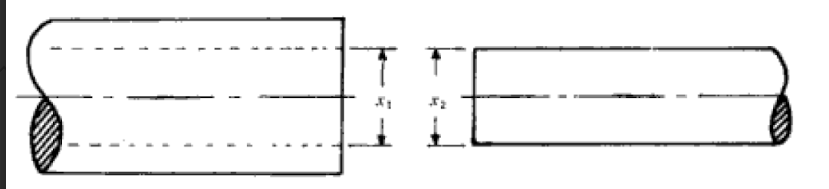

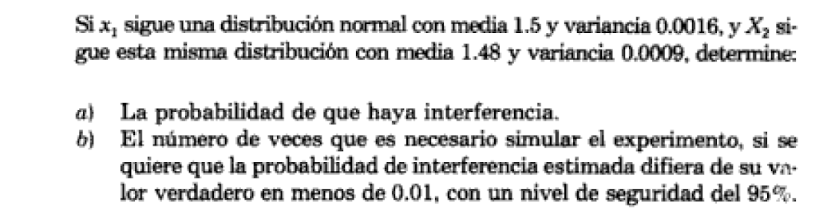

Solución:

Primero lo haremos de manera analítica para posterior de manera programada.

**a) ANALÍTICA**

Sean:

$X_{1}\sim N(\mu_{1}=1.5, \sigma^2_{1}= 0.16$)

$\sigma_{1}= 0.4$

$X_{2}\sim N(\mu_{2}=1.48, \sigma^2_{2}= 0.09$)

$\sigma_{2}= 0.3$

Definimos la variable de diferencia:

D= $X_1 - X_2$


Por propiedades de distribución normal:

$\mu_{D}= \mu_{1} -\mu_{2}$ = 1.50-1.48

$\mu_{D}$= 0.02


Ahora por desviación estándar:

$\sigma^2_{D} = \sigma^2_{1} + \sigma^2_{2}$ = 0.16 + 0.09

$\sigma^2_{D}= 2.5$ y $\sigma_{D} = 0.5$

por lo tanto D $\sim$ N (0.02, 0.25)

Donde la condición de la interferencia $X_{1}$ < $X_{2}$ es equivalente a:

D < 0

es decir, estandarizando:

P(D<0)= P(Z < $\frac {0-0.02}{0.5})$

P(Z < -0.04)


Usamos la tabla de distribución normal estándar:

P(Z < -0.04)= 1- P(Z < 0.04) = 1 - 0.5160)= 0.4840  

Por lo tanto:

*P(*interferecia*)= 0.4840*

**a) PROGRAMADA**

Ahora de manera programada:


In [15]:
import numpy as np
import random as r
import matplotlib.pyplot as plt


In [18]:
def Muller_Normal (n):
    muestras=[ ]
    for _ in range(n // 2 + 1):
        u1 = r.random()
        u2 = r.random()
        z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
        z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)
        muestras.append(z1)
        muestras.append(z2)
    return muestras[:n]

def simular_interferencia(n):
    mu1, sigma1 = 1.5, 0.4    # varianza 0.16
    mu2, sigma2 = 1.48, 0.3   # varianza 0.09

    zs =  Muller_Normal(2 * n)
    interferencias = 0

    for i in range(n):
        z1 = zs[2*i]
        z2 = zs[2*i + 1]

        x1 = mu1 + sigma1 * z1
        x2 = mu2 + sigma2 * z2

        if x1 < x2:
            interferencias += 1

    p_est = interferencias / n

# Parte (a) con X_{1}
n_sim = 100000
print(f"Probabilidad de que exista interferencia (n={n_sim}): {p_estimado:.6f}")
print(f"De manera analítica: 0.4840")

Probabilidad de que exista interferencia (n=100000): 0.487830
De manera analítica: 0.4840


In [19]:
k= Muller_Normal(1000)

(array([ 1.,  0.,  0.,  0.,  0.,  1.,  0.,  1.,  1.,  0.,  0.,  1.,  0.,
         1.,  1.,  2.,  3.,  5.,  0.,  3.,  7.,  8., 11., 11.,  8., 15.,
        13.,  8., 23., 17., 17., 20., 21., 22., 16., 28., 16., 20., 21.,
        29., 24., 37., 25., 25., 28., 27., 31., 21., 27., 34., 26., 35.,
        22., 23., 28., 21., 17., 13., 20., 18., 16., 11., 15., 14.,  6.,
        10.,  6.,  8.,  6., 13.,  5.,  3.,  3.,  5.,  4.,  6.,  5.,  1.,
         3.,  2.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  1.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-3.19639689e+00, -3.12540702e+00, -3.05441715e+00, -2.98342728e+00,
        -2.91243741e+00, -2.84144754e+00, -2.77045767e+00, -2.69946780e+00,
        -2.62847793e+00, -2.55748806e+00, -2.48649819e+00, -2.41550832e+00,
        -2.34451845e+00, -2.27352858e+00, -2.20253871e+00, -2.13154884e+00,
        -2.06055897e+00, -1.98956910e+00, -1.91857923e+00, -1.84758936e+00,
        -1.77659949e+00, -1.70560962e+00, -1.63461975e

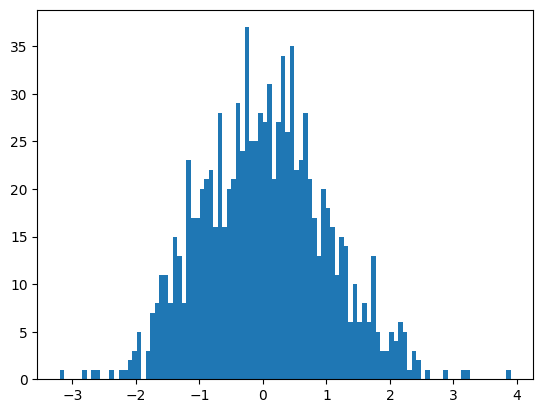

In [20]:
plt.hist(k, bins=100)

Por último resolvemos inciso b)

De igual manera primero analítica para posteriormente de manera programada:

**b) ANALÍTICA**

Para resolver ocuparemos p= 0.484, entonces:

n= $\frac{(z^2)* p(1-p)}{\epsilon ^2}$

donde:
z= 1.96, $\epsilon$=0.01

p(1-p)= 0.484*0.516 = 0.2497

entonces sustituyendo en la fórmula es:

n= $\frac{(1.96^2)* (0.2497)}{0.01^2}$ = $\frac{(3.8416)* (0.2497)}{(0.0001)}$

n=
$\frac{(0.9593}{(0.0001)}$

Concluimos que:

$n \sim 9593$

**b) PROGRAMADO**

In [36]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

def generar_normal():
    u1 = r.random()
    u2 = r.random()
    z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
    return z

def un_ensamble():
    x1 = 1.5 + 0.4 * generar_normal()   # N(1.5, 0.16)
    x2 = 1.48 + 0.3 * generar_normal()  # N(1.48, 0.09)
    return 1 if x1 < x2 else 0

def simular(n):
    total = 0
    for _ in range(n):
        total += un_ensamble()
    return total / n
# Estimar p con una muestra inicial
p_estimado = simular(20000)
print(f"Probabilidad estimada (muestra inicial): {p_estimado:.4f}")

# Parámetros
z = 1.96        # para 95% de confianza
epsilon = 0.01  # precisión deseada

# Fórmula para calcular n necesario
n_necesario = int(np.ceil((z**2 * p_estimado * (1 - p_estimado)) / (epsilon**2)))
print(f"n necesario según fórmula: {n_necesario}")

# Verificar que con ese n se cumple la condición
p_verificacion = simular(n_necesario)
error_estandar = np.sqrt(p_verificacion * (1 - p_verificacion) / n_necesario)
margen = 1.96 * error_estandar

print(f"\nVerificación con n = {n_necesario}:")
print(f"  p estimado = {p_verificacion:.4f}")
print(f"  Error estándar = {error_estandar:.5f}")
print(f"\nRespuesta: Se necesitan {n_necesario} simulaciones aproximadamente")

Probabilidad estimada (muestra inicial): 0.4815
n necesario según fórmula: 9591

Verificación con n = 9591:
  p estimado = 0.4858
  Error estándar = 0.00510

Respuesta: Se necesitan 9591 simulaciones aproximadamente
